# Group 4 ML Project
- Jean Paul Collazo
- Janeth Lucero Garcia Rodriguez
- Daniel Graham

Using the dataset located at https://archive.ics.uci.edu/dataset/2/adult 

Best model: XGBoost

Environment based on Anaconda (python >= 3.13 and having install xgboost `conda install xgboost`)

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier # type: ignore


### Load the dataset and perform EDA and feature engineering / preprocessing.

#### Load dataset and data cleansing

In [2]:
all_columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 
    'capital-loss', 'hours-per-week', 'native-country', 'income']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
target_feature = 'income'
random_state_value = 48

df = pd.read_csv('adult.data.csv', header=None, names=all_columns)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
print("Dataset shape:", df.shape)
print()

df.info()

Dataset shape: (32561, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [5]:
for column in df.columns:
    count = df[column].astype(str).str.strip().eq('?').sum()
    if count > 0:
        print(f"{column}: {count}")

workclass: 1836
occupation: 1843
native-country: 583


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 24


In [7]:
for column in categorical_features + [target_feature]:
    df[column] = df[column].str.strip()

# Convert ? into actual missing values
df.replace('?', np.nan, inplace=True)

In [8]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

#### Explore feature statistics 

In [9]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
df['income'].value_counts(normalize=True).mul(100).round(2)

income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64

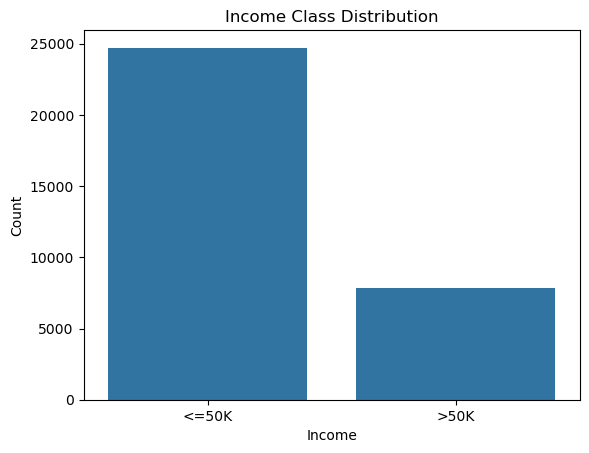

In [11]:
sns.countplot(data=df, x='income')
plt.title('Income Class Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

In [12]:
df[numerical_features].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [13]:
income_numeric_summary = df.groupby('income')[['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']].mean().round(2)

income_numeric_summary

,age,education-num,hours-per-week,capital-gain,capital-loss
income,,,,,
<=50K,36.78,9.60,38.84,148.75,53.14
>50K,44.25,11.61,45.47,4006.14,195.00


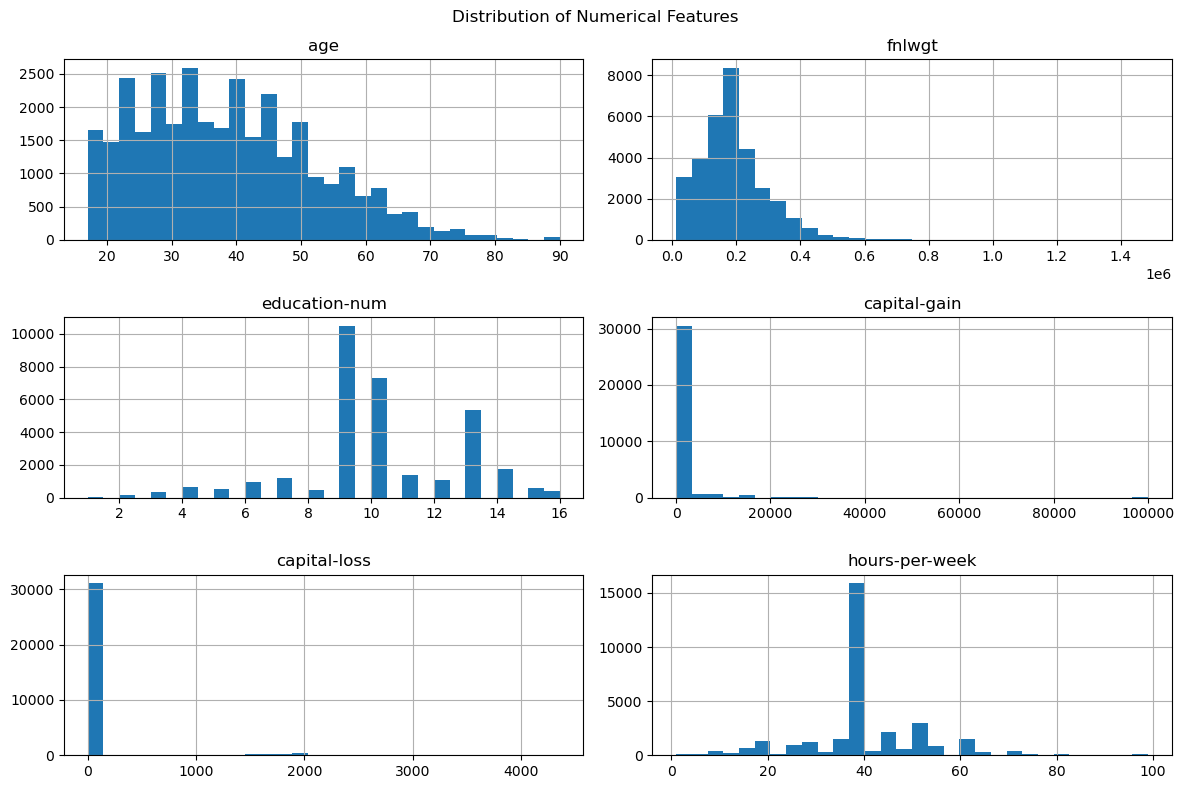

In [14]:
df[numerical_features].hist(
    figsize=(12, 8),
    bins=30
)
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

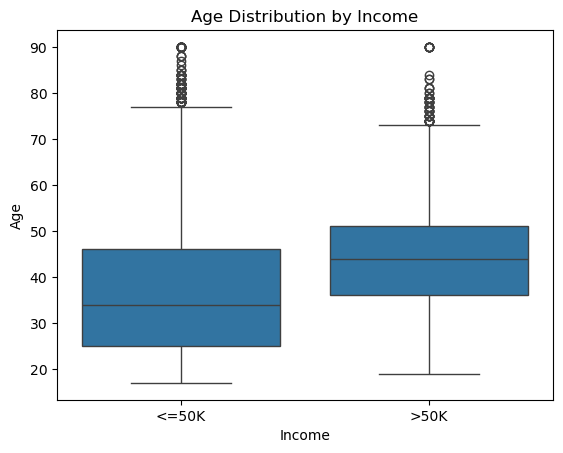

In [15]:
sns.boxplot(data=df, x='income', y='age')
plt.title('Age Distribution by Income')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

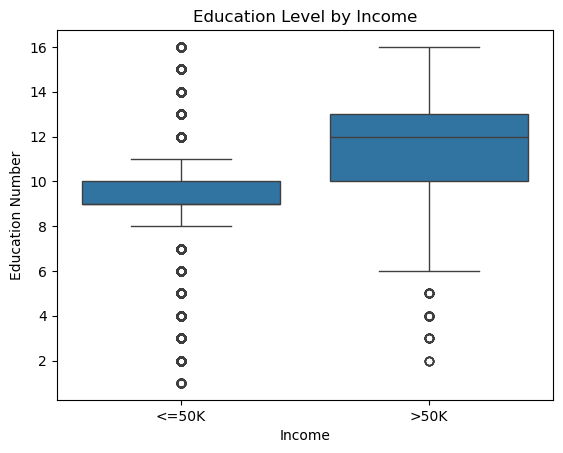

In [16]:
sns.boxplot(data=df, x='income', y='education-num')
plt.title('Education Level by Income')
plt.xlabel('Income')
plt.ylabel('Education Number')
plt.show()

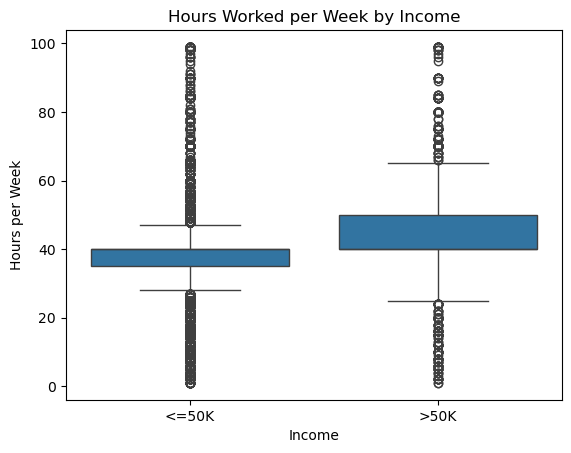

In [17]:
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours Worked per Week by Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

In [18]:
education_income = pd.crosstab(
    df['education'],
    df['income'],
    normalize='index'
) * 100

education_income.round(2)

income,<=50K,>50K
education,,
10th,93.35,6.65
11th,94.89,5.11
12th,92.38,7.62
1st-4th,96.43,3.57
5th-6th,95.20,4.80
7th-8th,93.81,6.19
9th,94.75,5.25
Assoc-acdm,75.16,24.84
Assoc-voc,73.88,26.12


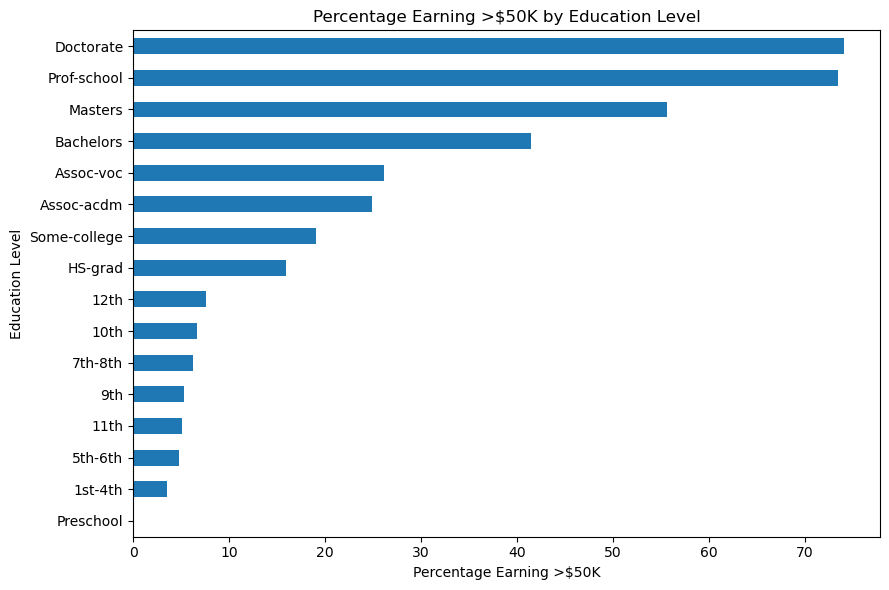

In [19]:
education_income['>50K'].sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)
plt.title('Percentage Earning >$50K by Education Level')
plt.xlabel('Percentage Earning >$50K')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

In [20]:
occupation_income = pd.crosstab(
    df['occupation'],
    df['income'],
    normalize='index'
) * 100
occupation_income.round(2)

income,<=50K,>50K
occupation,,
Adm-clerical,86.55,13.45
Armed-Forces,88.89,11.11
Craft-repair,77.34,22.66
Exec-managerial,51.60,48.40
Farming-fishing,88.43,11.57
Handlers-cleaners,93.72,6.28
Machine-op-inspct,87.51,12.49
Other-service,95.84,4.16
Priv-house-serv,99.33,0.67


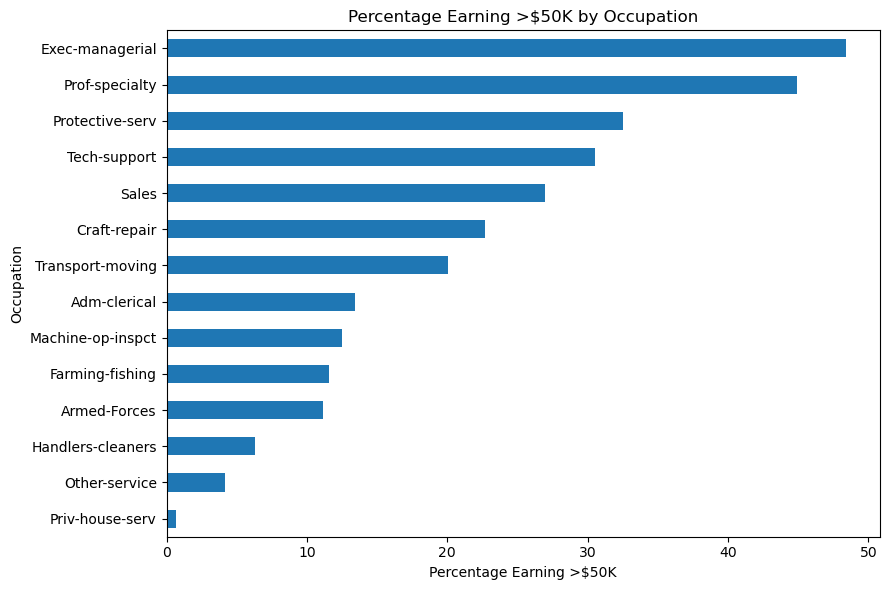

In [21]:
occupation_income['>50K'].sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)
plt.title('Percentage Earning >$50K by Occupation')
plt.xlabel('Percentage Earning >$50K')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

#### Set up pipeline

In [32]:
X = df[categorical_features + numerical_features]
y = df[target_feature].apply(lambda x: 1 if x == '>50K' else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state_value, stratify=y)

categorical_transformer = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
numerical_transformer = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### XGBoost (no hyperparameter tuning)

In [33]:
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

xgb_model = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", xgb)])
xgb_model.fit(X_train, y_train)
predictions = xgb_model.predict(X_test)
predictions_proba = xgb_model.predict_proba(X_test)[:, 1]
confusion = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(confusion)
print("\nClassification Report:")
print(classification_report(y_test, predictions))
print("\nPredicted Probabilities:")
print(predictions_proba)
print("Accuracy:", np.mean(predictions == y_test.values))
print("Precision:", confusion[1, 1] / (confusion[0, 1] + confusion[1, 1]))
print("Recall:", confusion[1, 1] / (confusion[1, 0] + confusion[1, 1]))
# F1 score
xgb_f1 = f1_score(y_test, predictions)
print("F1 Score:", xgb_f1)
# ROC AUC
xgb_auc = roc_auc_score(y_test, predictions_proba)
print("XGB AUC:", xgb_auc)
# Cross-validation accuracy (5-fold)
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print("XGB CV Accuracy scores:", xgb_cv_scores)
print("XGB CV Accuracy (mean):", np.mean(xgb_cv_scores))

Confusion Matrix:
[[4636  309]
 [ 507 1061]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4945
           1       0.77      0.68      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.87      0.87      6513


Predicted Probabilities:
[0.00713146 0.00684308 0.01322436 ... 0.01594697 0.72776353 0.04224239]
Accuracy: 0.8747121142330723
Precision: 0.7744525547445256
Recall: 0.6766581632653061
F1 Score: 0.7222600408441117
XGB AUC: 0.9304233043065558
XGB CV Accuracy scores: [0.86933825 0.8713145  0.87423219 0.87883907 0.87714988]
XGB CV Accuracy (mean): 0.8741747746238764


### XGBoost (hyperparameter tuning)

In [34]:
# Hyperparameter tuning for XGBoost using GridSearchCV
xgb_param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state_value)

xgb_grid = GridSearchCV(xgb_model, param_grid=xgb_param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)

xgb_grid.fit(X_train, y_train)
print('XGB Best Params:', xgb_grid.best_params_)
print('XGB Best CV Accuracy:', xgb_grid.best_score_)

# Evaluate best estimator on test set
xgb_best = xgb_grid.best_estimator_
xgb_preds = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

xgb_conf = confusion_matrix(y_test, xgb_preds)
print('\nXGB Confusion Matrix:')
print(xgb_conf)
print('\nXGB Classification Report:')
print(classification_report(y_test, xgb_preds))
print('XGB Accuracy:', np.mean(xgb_preds == y_test.values))
print('XGB Precision:', xgb_conf[1, 1] / (xgb_conf[0, 1] + xgb_conf[1, 1]))
print('XGB Recall:', xgb_conf[1, 1] / (xgb_conf[1, 0] + xgb_conf[1, 1]))
print('XGB F1 Score:', f1_score(y_test, xgb_preds))
print('XGB AUC:', roc_auc_score(y_test, xgb_proba))

# Cross-validation accuracy for the pipeline on full data
xgb_cv_scores = cross_val_score(xgb_best, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print('XGB CV Accuracy scores:', xgb_cv_scores)
print('XGB CV Accuracy (mean):', np.mean(xgb_cv_scores))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
XGB Best Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 500, 'classifier__subsample': 1.0}
XGB Best CV Accuracy: 0.8741172907219124

XGB Confusion Matrix:
[[4630  315]
 [ 503 1065]]

XGB Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4945
           1       0.77      0.68      0.72      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.81      0.82      6513
weighted avg       0.87      0.87      0.87      6513

XGB Accuracy: 0.8744050360816827
XGB Precision: 0.7717391304347826
XGB Recall: 0.6792091836734694
XGB F1 Score: 0.7225237449118046
XGB AUC: 0.9308272373661295
XGB CV Accuracy scores: [0.87440504 0.87100737 0.87116093 0.875      0.87976044]
XGB CV Accuracy (mean): 0.874266756602086
